In [2]:
# ==============================
# Standard Libraries
# ==============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# ==============================
# File Path
# ==============================
file_path = r"C:\Users\Lenovo\AI_ML\kidney_disease.csv"

# Load Dataset
df = pd.read_csv(file_path)

# ==============================
# Data Preprocessing
# ==============================
# from sklearn.model_selection import (
#     train_test_split,
#     StratifiedKFold,
#     cross_val_score,
   
#     MinMaxScaler

In [3]:
df


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


In [4]:
df.shape

(400, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [6]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [7]:
df.isnull().mean()*100

id                 0.00
age                2.25
bp                 3.00
sg                11.75
al                11.50
su                12.25
rbc               38.00
pc                16.25
pcc                1.00
ba                 1.00
bgr               11.00
bu                 4.75
sc                 4.25
sod               21.75
pot               22.00
hemo              13.00
pcv               17.50
wc                26.25
rc                32.50
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64

In [8]:
nums_col = df.select_dtypes(include = ['int64','float64']).columns
cats_col = df.select_dtypes(include='object').columns                                    

In [9]:
num_cols = nums_col.drop('id')
cats_col= cats_col.drop('classification')

In [10]:
import math

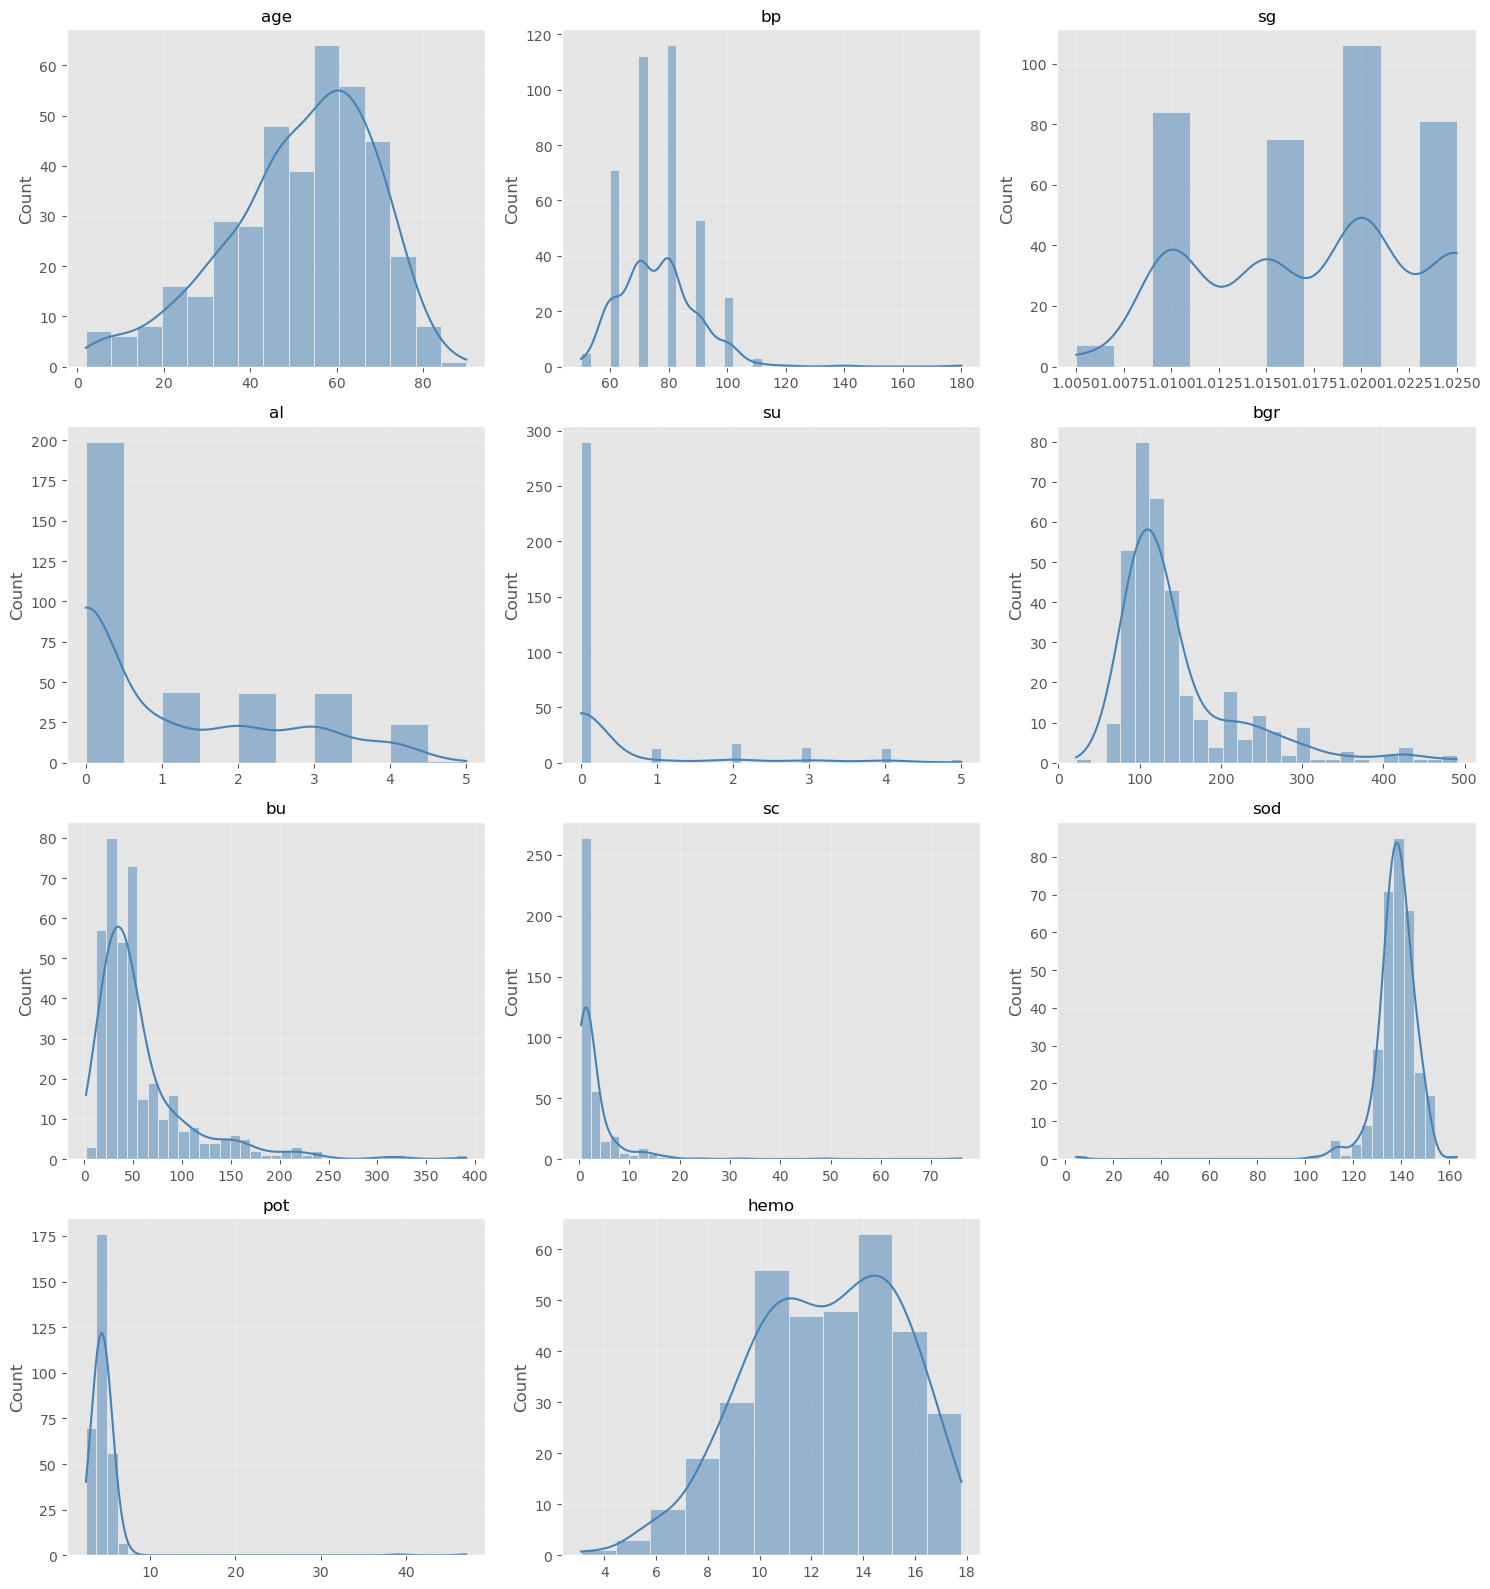

In [11]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


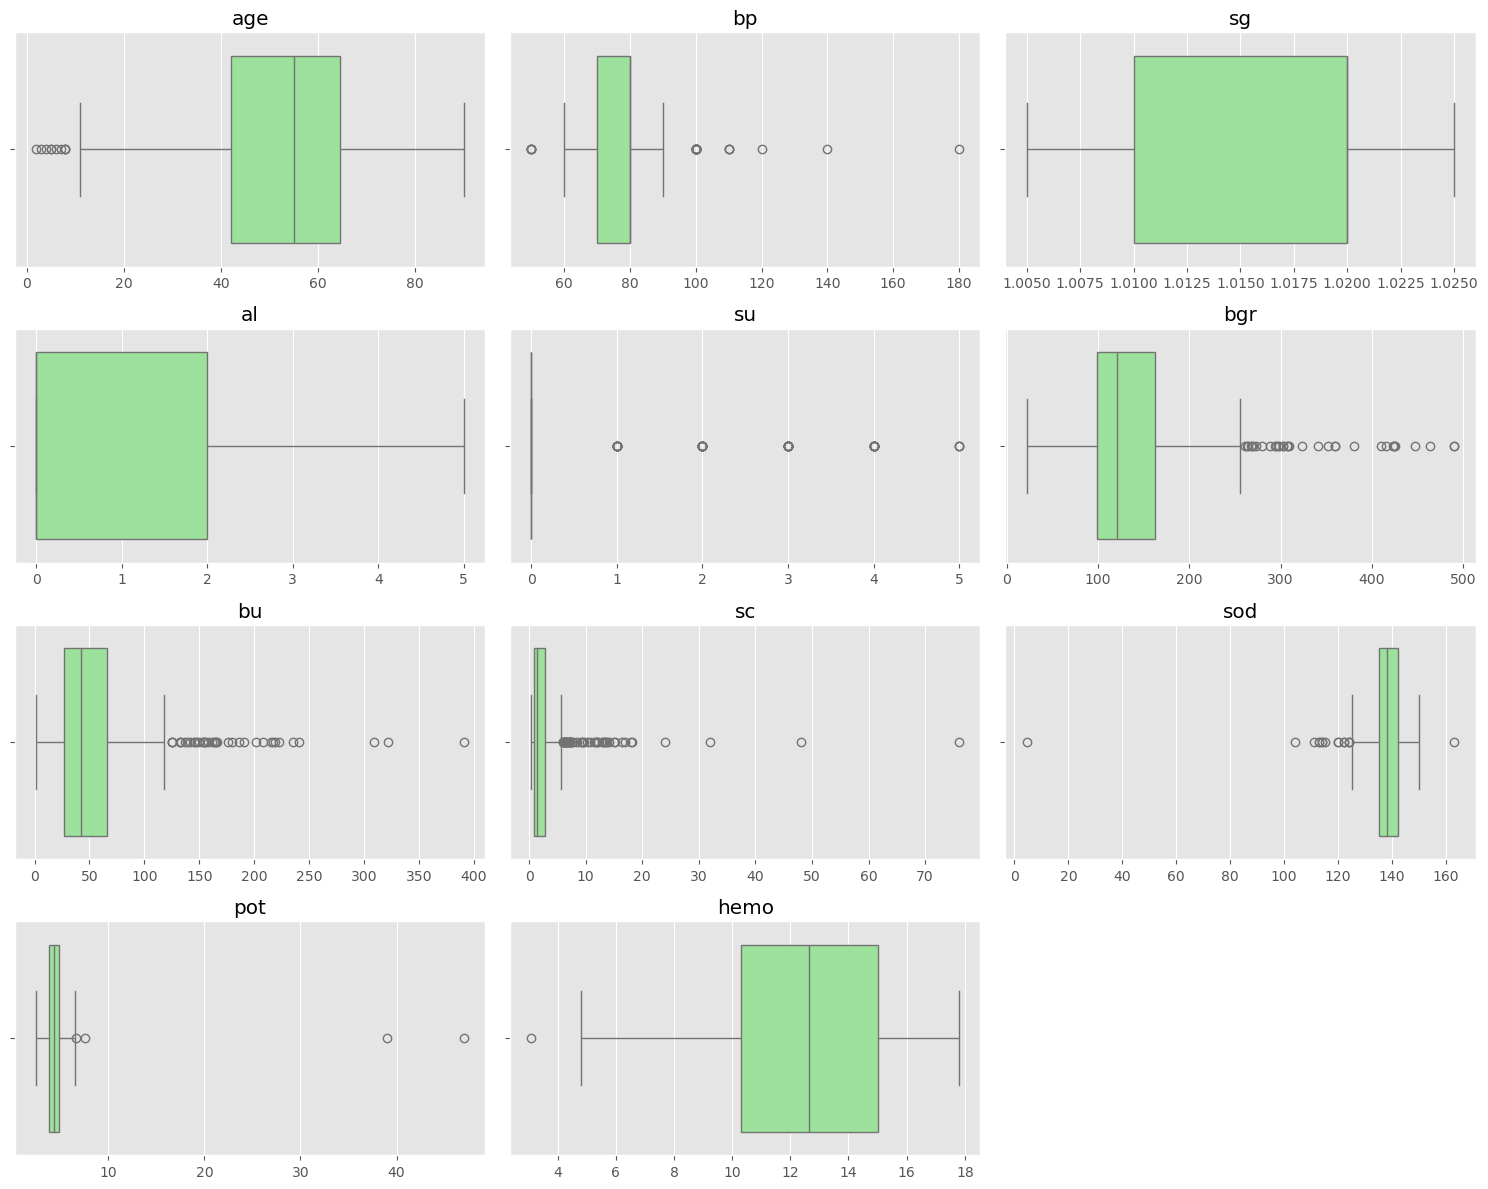

In [12]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
df.rename(columns={
    'id': 'Patient_ID',
    'age': 'Age',
    'bp': 'Blood_Pressure',
    'sg': 'Specific_Gravity',
    'al': 'Albumin',
    'su': 'Sugar',
    'rbc': 'Red_Blood_Cells',
    'pc': 'Pus_Cells',
    'pcc': 'Pus_Cell_Clumps',
    'ba': 'Bacteria',
    'bgr': 'Blood_Glucose_Random',
    'bu': 'Blood_Urea',
    'sc': 'Serum_Creatinine',
    'sod': 'Sodium',
    'pot': 'Potassium',
    'hemo': 'Hemoglobin',
    'pcv': 'Packed_Cell_Volume',
    'wc': 'White_Blood_Cell_Count',
    'rc': 'Red_Blood_Cell_Count',
    'htn': 'Hypertension',
    'dm': 'Diabetes_Mellitus',
    'cad': 'Coronary_Artery_Disease',
    'appet': 'Appetite',
    'pe': 'Pedal_Edema',
    'ane': 'Anemia',
    'classification': 'CKD_Classification'
}, inplace=True)

In [14]:
cols = ['Age','Blood_Pressure','Blood_Glucose_Random','Blood_Urea', 'Sodium']
for col in cols:
    df[col].fillna(df[col].mean(),inplace = True)

In [15]:
df['Specific_Gravity'].unique()

array([1.02 , 1.01 , 1.005, 1.015,   nan, 1.025])

In [16]:
df['Specific_Gravity'].fillna(df['Specific_Gravity'].mode()[0],inplace = True)

In [17]:
print(df['Albumin'].unique())
print(df['Sugar'].unique())

[ 1.  4.  2.  3.  0. nan  5.]
[ 0.  3.  4.  1. nan  2.  5.]


In [18]:
df['Albumin'].fillna(df['Albumin'].mode()[0],inplace = True)

In [19]:
# imputation on more
df['Albumin'].fillna(df['Albumin'].mode()[0], inplace=True)
df['Sugar'].fillna(df['Sugar'].mode()[0], inplace=True)

In [20]:
(df['Sugar'] == 0).sum()

np.int64(339)

In [21]:
df['Diabetes_Mellitus'].unique()

array(['yes', 'no', ' yes', '\tno', '\tyes', nan], dtype=object)

In [22]:
df['Diabetes_Mellitus'] = df['Diabetes_Mellitus'].str.strip()

In [23]:
df['Diabetes_Mellitus'] = df['Diabetes_Mellitus'].map({'yes':1,'no':0})

In [24]:
cols = ['Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease',
               'Pedal_Edema', 'Anemia']
for col in cols:
    print(f"{col}: {df[col].unique()}")

Hypertension: ['yes' 'no' nan]
Diabetes_Mellitus: [ 1.  0. nan]
Coronary_Artery_Disease: ['no' 'yes' '\tno' nan]
Pedal_Edema: ['no' 'yes' nan]
Anemia: ['no' 'yes' nan]


In [25]:
cat_cols = df.select_dtypes(include='object').columns

In [26]:
for col in cat_cols:
    df[col] = df[col].str.strip()

In [27]:
for col in cat_cols:
    pfor col in cat_cols:
    df[col] = df[col].str.strip()rint(f"{col}: {df[col].unique()}")

Red_Blood_Cells: [nan 'normal' 'abnormal']
Pus_Cells: ['normal' 'abnormal' nan]
Pus_Cell_Clumps: ['notpresent' 'present' nan]
Bacteria: ['notpresent' 'present' nan]
Packed_Cell_Volume: ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '?' '52' '14' '22' '18' '42' '17' '46' '23' '19'
 '25' '41' '26' '15' '21' '43' '20' '47' '9' '49' '50' '53' '51' '54']
White_Blood_Cell_Count: ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '7100' '11800' '9400' '5500' '5800' '13200'
 '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800' '6500'
 '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300' '12400'
 '10500' '4200' '4700' '10900' '8100' '9500' '2200' '12800' '11200'
 '19100' '?' '12300' '16700' '2600' '26400' '8800' '7400' '4900' '8000'

In [28]:
df.replace('?',np.nan,inplace = True)

In [29]:
df.dtypes

Patient_ID                   int64
Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cells                   object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume          object
White_Blood_Cell_Count      object
Red_Blood_Cell_Count        object
Hypertension                object
Diabetes_Mellitus          float64
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
CKD_Classification          object
dtype: object

In [30]:
cols = [
    'Packed_Cell_Volume',
    'White_Blood_Cell_Count',
    'Red_Blood_Cell_Count'
]

for col in cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')
    

In [31]:
df.dtypes

Patient_ID                   int64
Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cells                   object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension                object
Diabetes_Mellitus          float64
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
CKD_Classification          object
dtype: object

In [32]:
df['Hypertension']=df['Hypertension'].map({
    'yes':1,'no':0
})

In [33]:
df['Hypertension'].fillna(df['Hypertension'].mode()[0], inplace=True)

In [34]:
df['Hypertension'].unique()

array([1., 0.])

In [35]:
mapping = {
    'yes': 1, 'no': 0,
    'normal': 1, 'abnormal': 0,
    'present': 1, 'notpresent': 0,
    'good': 1, 'poor': 0,
    'ckd': 1, 'notckd': 0
}

cat_cols = [
    'Red_Blood_Cells',
    'Pus_Cells',
    'Pus_Cell_Clumps',
    'Bacteria',
    'Hypertension',
    'Diabetes_Mellitus',
    'Coronary_Artery_Disease',
    'Appetite',
    'Pedal_Edema',
    'Anemia',
    'CKD_Classification'
]
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Red_Blood_Cells: [nan 'normal' 'abnormal']
Pus_Cells: ['normal' 'abnormal' nan]
Pus_Cell_Clumps: ['notpresent' 'present' nan]
Bacteria: ['notpresent' 'present' nan]
Hypertension: [1. 0.]
Diabetes_Mellitus: [ 1.  0. nan]
Coronary_Artery_Disease: ['no' 'yes' nan]
Appetite: ['good' 'poor' nan]
Pedal_Edema: ['no' 'yes' nan]
Anemia: ['no' 'yes' nan]
CKD_Classification: ['ckd' 'notckd']


In [36]:
binary_cols = [
    'Red_Blood_Cells',
    'Pus_Cells',
    'Pus_Cell_Clumps',
    'Bacteria',
    'Hypertension',
    'Diabetes_Mellitus',
    'Coronary_Artery_Disease',
    'Appetite',
    'Pedal_Edema',
    'Anemia'
]

for col in binary_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [37]:
df.isnull().sum()

Patient_ID                   0
Age                          0
Blood_Pressure               0
Specific_Gravity             0
Albumin                      0
Sugar                        0
Red_Blood_Cells              0
Pus_Cells                    0
Pus_Cell_Clumps              0
Bacteria                     0
Blood_Glucose_Random         0
Blood_Urea                   0
Serum_Creatinine            17
Sodium                       0
Potassium                   88
Hemoglobin                  52
Packed_Cell_Volume          71
White_Blood_Cell_Count     106
Red_Blood_Cell_Count       131
Hypertension                 0
Diabetes_Mellitus            0
Coronary_Artery_Disease      0
Appetite                     0
Pedal_Edema                  0
Anemia                       0
CKD_Classification           0
dtype: int64

In [38]:
df['Serum_Creatinine'].value_counts().sort_index()

Serum_Creatinine
0.40      1
0.50     23
0.60     18
0.70     22
0.80     17
0.90     22
1.00     23
1.10     24
1.20     40
1.30      8
1.40      7
1.50      9
1.60      8
1.70      9
1.80      7
1.90      6
2.00      5
2.10      5
2.20     10
2.30      3
2.40      3
2.50      7
2.60      1
2.70      5
2.80      7
2.90      3
3.00      2
3.20      5
3.25      1
3.30      5
3.40      3
3.60      1
3.80      1
3.90      4
4.00      3
4.10      2
4.30      1
4.40      2
4.60      2
5.20      2
5.30      3
5.60      2
5.90      1
6.00      2
6.10      2
6.30      2
6.40      1
6.50      2
6.70      2
6.80      1
7.10      1
7.20      2
7.30      4
7.50      1
7.70      1
8.50      1
9.20      1
9.30      1
9.60      1
9.70      1
10.20     1
10.80     1
11.50     1
11.80     1
11.90     1
12.00     1
12.20     1
12.80     1
13.00     1
13.30     1
13.40     1
13.50     1
13.80     1
14.20     1
15.00     1
15.20     1
16.40     1
16.90     1
18.00     1
18.10     1
24.00     1
32.00     1

In [39]:
df['Potassium'].value_counts().sort_index()

Potassium
2.5      2
2.7      1
2.8      1
2.9      3
3.0      2
3.2      3
3.3      3
3.4      5
3.5     30
3.6      8
3.7     12
3.8     14
3.9     14
4.0     14
4.1     14
4.2     14
4.3     12
4.4     14
4.5     13
4.6      7
4.7     17
4.8     16
4.9     27
5.0     30
5.1      1
5.2      5
5.3      4
5.4      3
5.5      3
5.6      2
5.7      4
5.8      2
5.9      2
6.3      3
6.4      1
6.5      2
6.6      1
7.6      1
39.0     1
47.0     1
Name: count, dtype: int64

In [40]:
mean_cols = [
    'Age',
    'Blood_Pressure',
    'Blood_Glucose_Random',
    'Blood_Urea',
    'Sodium',
    'Hemoglobin'
]

for col in mean_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [42]:
from sklearn.impute import KNNImputer

cols = ['Sugar',
       'Blood_Glucose_Random',
       'Diabetes_Mellitus',
       'Albumin',
       'Specific_Gravity']
imputer = KNNImputer(n_neighbors=5,weights='distance')

df[cols] = imputer.fit_transform(df[cols])

In [43]:
median_cols = ['Serum_Creatinine']

for col in median_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [44]:
for col in ['Packed_Cell_Volume',
            'White_Blood_Cell_Count',
            'Red_Blood_Cell_Count']:
    print(col, df[col].nunique())

Packed_Cell_Volume 42
White_Blood_Cell_Count 89
Red_Blood_Cell_Count 45


In [45]:
df[['Packed_Cell_Volume',
    'White_Blood_Cell_Count',
    'Red_Blood_Cell_Count']].dtypes

Packed_Cell_Volume        float64
White_Blood_Cell_Count    float64
Red_Blood_Cell_Count      float64
dtype: object

In [46]:
df[['Packed_Cell_Volume',
    'White_Blood_Cell_Count',
    'Red_Blood_Cell_Count']].isnull().sum()

Packed_Cell_Volume         71
White_Blood_Cell_Count    106
Red_Blood_Cell_Count      131
dtype: int64

In [47]:
df['Packed_Cell_Volume'] = pd.to_numeric(df['Packed_Cell_Volume'])
df['White_Blood_Cell_Count'] = pd.to_numeric(df['White_Blood_Cell_Count'])
df['Red_Blood_Cell_Count'] = pd.to_numeric(df['Red_Blood_Cell_Count'])

In [48]:
for col in ['Packed_Cell_Volume',
            'White_Blood_Cell_Count',
            'Red_Blood_Cell_Count']:
    print(f"\n{col}")
    print(df[col].dtype)
    print(df[col].describe())


Packed_Cell_Volume
float64
count    329.000000
mean      38.884498
std        8.990105
min        9.000000
25%       32.000000
50%       40.000000
75%       45.000000
max       54.000000
Name: Packed_Cell_Volume, dtype: float64

White_Blood_Cell_Count
float64
count      294.000000
mean      8406.122449
std       2944.474190
min       2200.000000
25%       6500.000000
50%       8000.000000
75%       9800.000000
max      26400.000000
Name: White_Blood_Cell_Count, dtype: float64

Red_Blood_Cell_Count
float64
count    269.000000
mean       4.707435
std        1.025323
min        2.100000
25%        3.900000
50%        4.800000
75%        5.400000
max        8.000000
Name: Red_Blood_Cell_Count, dtype: float64


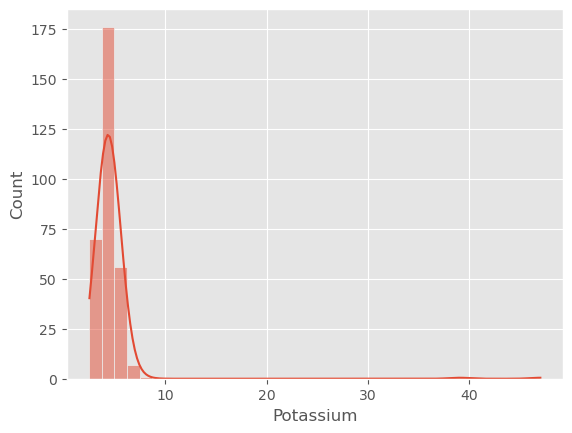

In [49]:
sns.histplot(df['Potassium'], kde=True)
plt.show()

In [50]:
# Mean Imputation
mean_cols = [
    'Packed_Cell_Volume',
    'Red_Blood_Cell_Count'
]

for col in mean_cols:
    df[col].fillna(df[col].mean(), inplace=True)

In [51]:
# Median Imputation
median_cols = [
    'Serum_Creatinine',
    'White_Blood_Cell_Count'
]

for col in median_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [52]:
df[df['Potassium'] > 10][['Potassium']]

,Potassium
61,39.0
128,47.0


In [53]:
# Mean Imputation
mean_cols = [
    'Packed_Cell_Volume',
    'Red_Blood_Cell_Count'
]

for col in mean_cols:
    df[col].fillna(df[col].mean(), inplace=True)


# Median Imputation
median_cols = [
    'Serum_Creatinine',
    'White_Blood_Cell_Count',
    'Potassium'
]

for col in median_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [54]:
df.isnull().sum()

Patient_ID                 0
Age                        0
Blood_Pressure             0
Specific_Gravity           0
Albumin                    0
Sugar                      0
Red_Blood_Cells            0
Pus_Cells                  0
Pus_Cell_Clumps            0
Bacteria                   0
Blood_Glucose_Random       0
Blood_Urea                 0
Serum_Creatinine           0
Sodium                     0
Potassium                  0
Hemoglobin                 0
Packed_Cell_Volume         0
White_Blood_Cell_Count     0
Red_Blood_Cell_Count       0
Hypertension               0
Diabetes_Mellitus          0
Coronary_Artery_Disease    0
Appetite                   0
Pedal_Edema                0
Anemia                     0
CKD_Classification         0
dtype: int64

In [55]:
df['CKD_Classification'].unique()

array(['ckd', 'notckd'], dtype=object)

In [56]:
df['CKD_Classification'] = df['CKD_Classification'].map({
    'ckd': 1,
    'notckd': 0
})

In [57]:
print(df.dtypes)

Patient_ID                   int64
Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cells                   object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension               float64
Diabetes_Mellitus          float64
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
CKD_Classification           int64
dtype: object


In [58]:
cols = ['Sugar',
       'Blood_Glucose_Random',
       'Diabetes_Mellitus',
       'Albumin',
       'Specific_Gravity']
imputer = KNNImputer(n_neighbors=5,weights='distance')

df[cols] = imputer.fit_transform(df[cols])

In [59]:
print(df.select_dtypes(include='object').columns.tolist())

['Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria', 'Coronary_Artery_Disease', 'Appetite', 'Pedal_Edema', 'Anemia']


In [60]:
df.dtypes

Patient_ID                   int64
Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells             object
Pus_Cells                   object
Pus_Cell_Clumps             object
Bacteria                    object
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension               float64
Diabetes_Mellitus          float64
Coronary_Artery_Disease     object
Appetite                    object
Pedal_Edema                 object
Anemia                      object
CKD_Classification           int64
dtype: object

In [61]:
mapping = {
    'normal': 1,
    'abnormal': 0,
    'present': 1,
    'notpresent': 0,
    'yes': 1,
    'no': 0,
    'good': 1,
    'poor': 0,
    'ckd': 1,
    'notckd': 0
}

cat_cols = [
    'Red_Blood_Cells',
    'Pus_Cells',
    'Pus_Cell_Clumps',
    'Bacteria',
    'Coronary_Artery_Disease',
    'Appetite',
    'Pedal_Edema',
    'Anemia'
]

for col in cat_cols:
    df[col] = df[col].map(mapping)

In [62]:
print(df.dtypes)

Patient_ID                   int64
Age                        float64
Blood_Pressure             float64
Specific_Gravity           float64
Albumin                    float64
Sugar                      float64
Red_Blood_Cells              int64
Pus_Cells                    int64
Pus_Cell_Clumps              int64
Bacteria                     int64
Blood_Glucose_Random       float64
Blood_Urea                 float64
Serum_Creatinine           float64
Sodium                     float64
Potassium                  float64
Hemoglobin                 float64
Packed_Cell_Volume         float64
White_Blood_Cell_Count     float64
Red_Blood_Cell_Count       float64
Hypertension               float64
Diabetes_Mellitus          float64
Coronary_Artery_Disease      int64
Appetite                     int64
Pedal_Edema                  int64
Anemia                       int64
CKD_Classification           int64
dtype: object


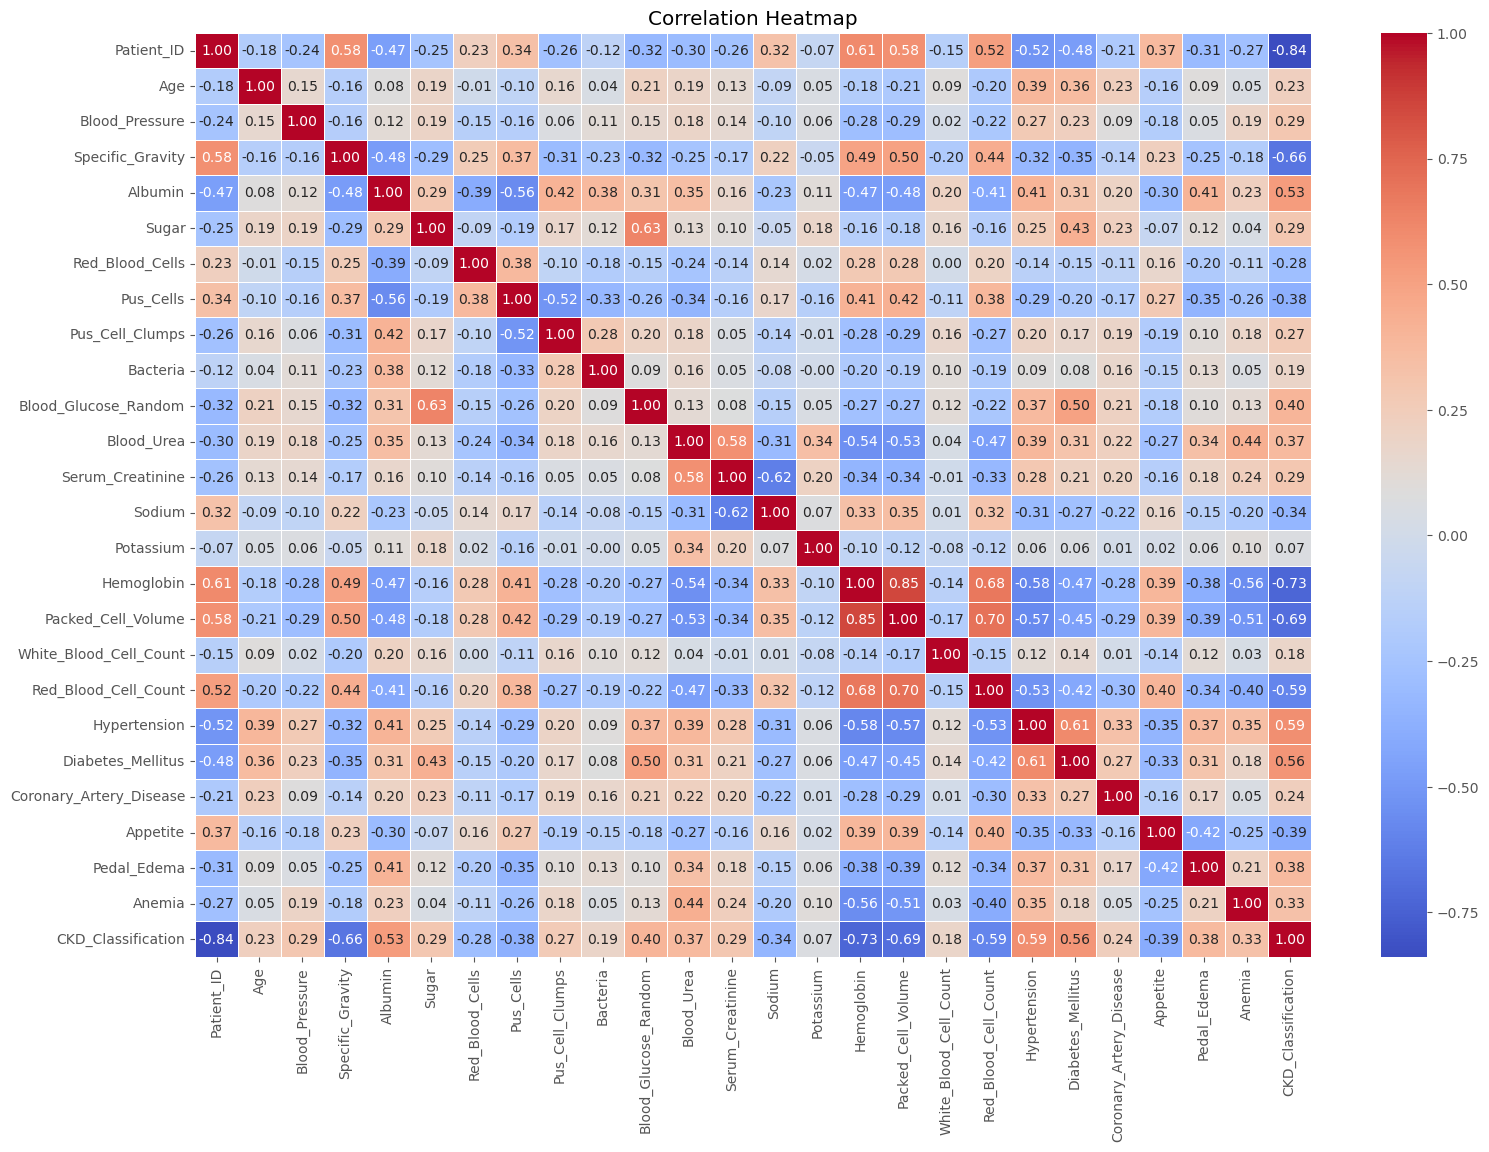

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [64]:
corr = df.corr()['CKD_Classification'].sort_values(ascending=False)
print(corr)

CKD_Classification         1.000000
Hypertension               0.590438
Diabetes_Mellitus          0.559060
Albumin                    0.531562
Blood_Glucose_Random       0.401374
Pedal_Edema                0.375154
Blood_Urea                 0.372033
Anemia                     0.325396
Sugar                      0.294555
Serum_Creatinine           0.291245
Blood_Pressure             0.290600
Pus_Cell_Clumps            0.265313
Coronary_Artery_Disease    0.236088
Age                        0.225405
Bacteria                   0.186871
White_Blood_Cell_Count     0.177571
Potassium                  0.065218
Red_Blood_Cells           -0.282642
Sodium                    -0.342288
Pus_Cells                 -0.375154
Appetite                  -0.393341
Red_Blood_Cell_Count      -0.590913
Specific_Gravity          -0.659504
Packed_Cell_Volume        -0.690060
Hemoglobin                -0.729628
Patient_ID                -0.838528
Name: CKD_Classification, dtype: float64


In [65]:
df.drop(columns='Patient_ID',inplace = True)

In [66]:
X = df.drop(columns = 'CKD_Classification')
y = df['CKD_Classification']

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size =0.2,
    random_state = 42,
    stratify = y
)


In [69]:
corr_matrix = X.corr().abs()

high_corr = (
    corr_matrix.where(corr_matrix > 0.85)
               .stack()
               .reset_index()
)

high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr = high_corr[high_corr['Feature 1'] != high_corr['Feature 2']]

print(high_corr)

             Feature 1           Feature 2  Correlation
15          Hemoglobin  Packed_Cell_Volume     0.854962
16  Packed_Cell_Volume          Hemoglobin     0.854962


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

accuracy = {}

In [72]:
from sklearn.metrics import accuracy_score

for name, model in models.items():

    if name in ['Logistic Regression', 'KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    accuracy[name] = accuracy_score(y_test, pred)

In [73]:
for model, score in accuracy.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.9875
KNN: 0.9750
SVM: 0.9875
Decision Tree: 0.9750
Random Forest: 1.0000


In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },

    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },

    'Decision Tree': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 3, 5, 10],
        'min_samples_split': [2, 5, 10]
    },

    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'criterion': ['gini', 'entropy']
    }
}

In [75]:
best_models = {}
best_scores = {}

for name, model in models.items():

    if name in ['Logistic Regression', 'KNN', 'SVM']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_tr, y_train)

    best_models[name] = grid.best_estimator_
    best_scores[name] = grid.best_score_

    print(f"{name}")
    print("Best Parameters:", grid.best_params_)
    print("Best CV Accuracy:", round(grid.best_score_, 4))
    print("-"*50)

Logistic Regression
Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best CV Accuracy: 0.9906
--------------------------------------------------
KNN
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV Accuracy: 0.9719
--------------------------------------------------
SVM
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9938
--------------------------------------------------
Decision Tree
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best CV Accuracy: 0.9875
--------------------------------------------------
Random Forest
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9906
--------------------------------------------------


In [76]:
from sklearn.metrics import accuracy_score

final_accuracy = {}

for name, model in best_models.items():

    if name in ['Logistic Regression', 'KNN', 'SVM']:
        pred = model.predict(X_test_scaled)
    else:
        pred = model.predict(X_test)

    final_accuracy[name] = accuracy_score(y_test, pred)

In [77]:


pd.DataFrame(
    final_accuracy.items(),
    columns=['Model', 'Test Accuracy']
).sort_values(by='Test Accuracy', ascending=False)

,Model,Test Accuracy
4,Random Forest,1.0000
0,Logistic Regression,0.9875
2,SVM,0.9750
3,Decision Tree,0.9750
1,KNN,0.9625


In [78]:
import joblib

In [101]:
best_model = best_models['Logistic Regression']

joblib.dump(best_model, 'model9.pkl')

['model9.pkl']

In [102]:
joblib.dump(scaler,'scaler2.pkl')

['scaler2.pkl']

In [103]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, 'features3.pkl')

['features3.pkl']

In [104]:
import os
print(os.listdir())

['.anaconda', '.android', '.cache', '.cisco', '.conda', '.continuum', '.cufflinks', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.python_history', '.streamlit', '.virtual_documents', '.vscode', '.vscode-shared', 'Adobe Premiere Pro Auto-Save', 'Adobe Premiere Pro Captured and Generated', 'AI_ML', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'cpps', 'diabetes_best_model.pkl', 'diabetes_expected_features.pkl', 'diabetes_scaler.pkl', 'Downloads', 'expected_columns.pkl', 'Favorites', 'features3.pkl', 'FirstWorkspace.prproj', 'heart_disease_model.pkl', 'kds.py', 'kidney.ipynb', 'Links', 'Local Settings', 'model.pkl', 'model1.pkl', 'model9.pkl', 'Model_Tuning.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{afdc5297-2f91-11f0-9fdd-24b2b96cdd9e}.TM.blf', 'NTUSER.DAT{afdc5297-2f91-11f0-9fdd-24b2b96cdd9e}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{afdc5

In [105]:
import os

files = ['model9.pkl', 'scaler2.pkl', 'features3.pkl']

for file in files:
    print(file, "->", os.path.exists(file))

model9.pkl -> True
scaler2.pkl -> True
features3.pkl -> True


In [106]:
print(features3)

NameError: name 'features3' is not defined

In [107]:
print(X.columns.tolist())

['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar', 'Red_Blood_Cells', 'Pus_Cells', 'Pus_Cell_Clumps', 'Bacteria', 'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Packed_Cell_Volume', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension', 'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite', 'Pedal_Edema', 'Anemia']
